In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
import statsmodels.stats.diagnostic as diag
from sklearn.naive_bayes import GaussianNB
#Metrics
from sklearn.metrics import make_scorer, accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import root_mean_squared_error
from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('ggplot')
random.seed(123)

In [2]:
carros = pd.read_csv("automobile_data.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'automobile_data.csv'

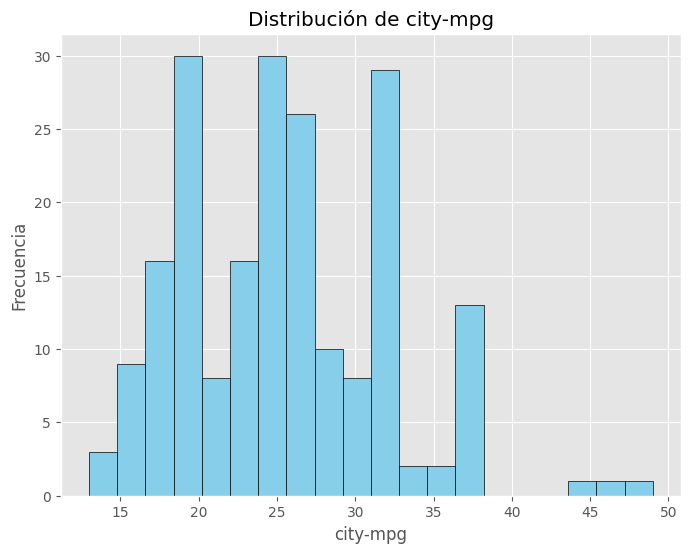

count    205.000000
mean      25.219512
std        6.542142
min       13.000000
25%       19.000000
50%       24.000000
75%       30.000000
max       49.000000
Name: city-mpg, dtype: float64


In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(carros['city-mpg'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribución de city-mpg')
plt.xlabel('city-mpg')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()
print(carros['city-mpg'].describe())

***Número de filas:*** 205  
***Número de atributos o columnas:*** 26 

### Información de los atributos:  

|Atributo:|Rango del atributo:|
|--------:|:-------------------:|
|1. symboling:|-3, -2, -1, 0, 1, 2, 3.|
|2. normalized-losses:|numérico 65 hasta 256.|
|3. make:|alfa-romero, audi, bmw, chevrolet, dodge, honda, isuzu, jaguar, mazda, mercedes-benz, mercury, mitsubishi, nissan, peugot, plymouth, porsche,  renault, saab, subaru, hastayota, volkswagen, volvo|
|4. fuel-type:|diesel, gas.|
|5. aspiration:|std, turbo.|
|6. num-of-doors:|four, two.|
|7. body-style:|hardtop, wagon, sedan, hatchback, convertible.|
|8. drive-wheels:|4wd, fwd, rwd.|
|9. engine-location:|front, rear.|
|10. wheel-base:|numérico desde 86.6 hasta 120.9.|
|11. length:|numérico desde 141.1 hasta 208.1.|
|12. width:|numérico desde 60.3 hasta 72.3.|
|13. height:|numérico desde 47.8 hasta 59.8.|
|14. curb-weight:|numérico desde 1488 hasta 4066.|
|15. engine-type:|dohc, dohcv, l, ohc, ohcf, ohcv, rotor.|
|16. num-of-cylinders:|eight, five, four, six, three, twelve, two.|
|17. engine-size:|numérico desde 61 to 326.|
|18. fuel-system:|1bbl, 2bbl, 4bbl, idi, mfi, mpfi, spdi, spfi.|
|19. bore:|numérico desde 2.54 hasta 3.94.|
|20. stroke:|numérico desde 2.07 hasta 4.17.|
|21. compression-ratio:|numérico desde 7 hasta 23.|
|22. horsepower:|numérico desde 48 hasta 288.|
|23. peak-rpm:|numérico desde 4150 hasta 6600.|
|24. city-mpg:|numérico desde 13 hasta 49.|
|25. highway-mpg:|numérico desde 16 hasta 54.|
|26. price:|numérico desde 5118 hasta 45400.|



## Variable Respuesta:

La variable que se pretende predecir es el consumo por galón en ciudad (city_mpg).
Separemos en conjuntos de entrenamiento y prueba.

## Conjuntos de entrenamiento y prueba.   

Se separarán en 70% de los datos en el conjunto de entrenamiento y 30% en el conjunto de prueba, usando un muestreo aleatorio simple.   

In [ ]:
carros["bore"] = carros["bore"].fillna(carros["bore"].median())
carros["stroke"] = carros["stroke"].fillna(carros["stroke"].median())
carros["horsepower"] = carros["horsepower"].fillna(carros["horsepower"].median())
carros["peak-rpm"] = carros["peak-rpm"].fillna(carros["peak-rpm"].median())
carros["price"] = carros["price"].fillna(carros["price"].median())


carros.pop("normalized-losses")

0        0
1        0
2        0
3      164
4      164
      ... 
200     95
201     95
202     95
203     95
204     95
Name: normalized-losses, Length: 205, dtype: int64

In [ ]:
print(carros.isnull().sum())

symboling            0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64


In [ ]:
print(carros.dtypes)

symboling              int64
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower             int64
peak-rpm               int64
city-mpg               int64
highway-mpg            int64
price                  int64
dtype: object


In [ ]:
y = carros.pop("city-mpg")
X = carros

In [ ]:
print(X)
print(X.columns)

     symboling         make fuel-type aspiration num-of-doors   body-style  \
0            3  alfa-romero       gas        std          two  convertible   
1            3  alfa-romero       gas        std          two  convertible   
2            1  alfa-romero       gas        std          two    hatchback   
3            2         audi       gas        std         four        sedan   
4            2         audi       gas        std         four        sedan   
..         ...          ...       ...        ...          ...          ...   
200         -1        volvo       gas        std         four        sedan   
201         -1        volvo       gas      turbo         four        sedan   
202         -1        volvo       gas        std         four        sedan   
203         -1        volvo    diesel      turbo         four        sedan   
204         -1        volvo       gas      turbo         four        sedan   

    drive-wheels engine-location  wheel-base  length  ...  num-

In [ ]:
X_train, X_test,y_train, y_test = train_test_split(X, y,test_size=0.3,train_size=0.7,random_state=0)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(143, 24)
(62, 24)
(143,)
(62,)


## Modelos

### Naive Bayes


Separando variables en numéricas vs categóricas

In [ ]:
numerical_columns_selector = selector(dtype_exclude=object)
categorical_columns_selector = selector(dtype_include=object)

numerical_columns = numerical_columns_selector(carros)
categorical_columns = categorical_columns_selector(carros)
print(categorical_columns)
print(numerical_columns)

['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders', 'fuel-system']
['symboling', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'highway-mpg', 'price']


Vamos a codificar las variables cualitativas con un onehot encoder y vamos a normalizar las variables cuantitativas

In [ ]:
categorical_preprocessor = OneHotEncoder(handle_unknown="ignore")
numerical_preprocessor = StandardScaler()
preprocessor = ColumnTransformer([
    ('one-hot-encoder', categorical_preprocessor, categorical_columns),
    ('standar-scaler', numerical_preprocessor,numerical_columns)
    ])
    

In [ ]:
#param_grid = {"max_depth": np.arange(2, 10, 1)}
pipeline = Pipeline(
    [('preprocessor',preprocessor),
     ('regressor', GaussianNB())])
#params = [{
#    "regressor__max_depth": np.arange(2, 10, 1)
#}]
pipeline.get_params()

{'memory': None,
 'steps': [('preprocessor',
   ColumnTransformer(transformers=[('one-hot-encoder',
                                    OneHotEncoder(handle_unknown='ignore'),
                                    ['make', 'fuel-type', 'aspiration',
                                     'num-of-doors', 'body-style', 'drive-wheels',
                                     'engine-location', 'engine-type',
                                     'num-of-cylinders', 'fuel-system']),
                                   ('standar-scaler', StandardScaler(),
                                    ['symboling', 'wheel-base', 'length', 'width',
                                     'height', 'curb-weight', 'engine-size',
                                     'bore', 'stroke', 'compression-ratio',
                                     'horsepower', 'peak-rpm', 'highway-mpg',
                                     'price'])])),
  ('regressor', GaussianNB())],
 'transform_input': None,
 'verbose': False,
 'preproce

El error es de 5.5 millas por galón aproximadamente. 

In [ ]:
modelo = pipeline.fit(X_train,y_train)
y_pred = modelo.predict(X_test)
rmse = root_mean_squared_error(y_test,y_pred)
rmse

5.497800146568889

## Vamos a tunnear el modelo - var_smoothing
Es un tipo de "regularización", nos permite "estabilizar" nuestros modelos.

Varianza pequeña → curva alta y delgada
#
Varianza grande → curva baja y ancha


- var_smoothing añade un pequeño valor a la varianza
- Evita problemas numéricos (divisiones por 0)
- Hace que las distribuciones sean un poco más “anchas” -> varianza "grande" 
- Reduce sensibilidad a ruido o valores extremos
- var_smoothing pequeño: se ajusta más a los datos, uno más grande puede perder precisión (underfitting)


In [ ]:
params =  [{
    "regressor__var_smoothing": np.logspace(0,-9, num=100)
}]
modelo = GridSearchCV(pipeline,param_grid=params,n_jobs=2, cv=5,scoring="neg_root_mean_squared_error")
modelo.fit(X_train,y_train)
modelo.best_params_

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


{'regressor__var_smoothing': 0.02848035868435802}

El mejor valor es 0.0285. Vamos a predecir con el mejor modelo.

In [ ]:
print(modelo.best_estimator_)
print('best score:')
print(modelo.best_score_)
y_mejor_pred = modelo.best_estimator_.predict(X_test)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('one-hot-encoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['make', 'fuel-type',
                                                   'aspiration', 'num-of-doors',
                                                   'body-style', 'drive-wheels',
                                                   'engine-location',
                                                   'engine-type',
                                                   'num-of-cylinders',
                                                   'fuel-system']),
                                                 ('standar-scaler',
                                                  StandardScaler(),
                                                  ['symboling', 'wheel-base',
                                                   'length', 'width', 'height',
     

In [ ]:
rmse_tunned = root_mean_squared_error(y_test,y_mejor_pred)
rmse_tunned

2.851145779868949

Como se puede observar el error del modelo que se mejoró tiene menos error medio cuadrado que el primer modelo. Por lo que sí mejoró

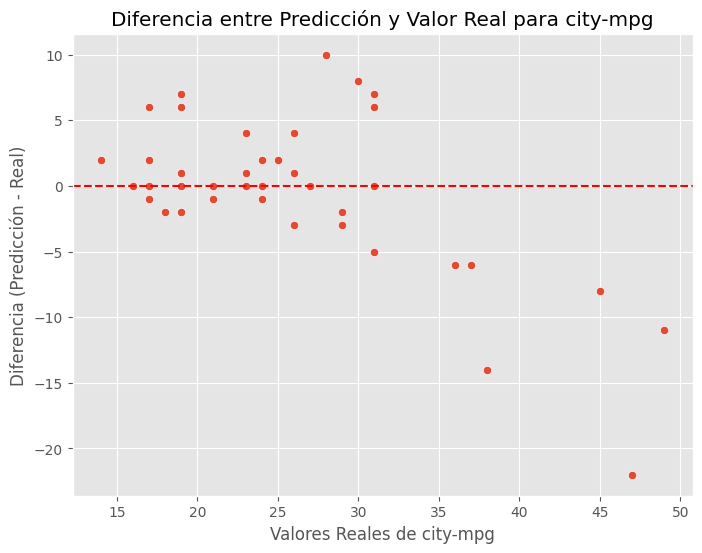

In [ ]:
# Calcula la diferencia entre las predicciones y los valores reales
differences = y_pred - y_test

# Crear un gráfico de dispersión entre las predicciones y los valores reales
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=differences)
plt.axhline(0, color='red', linestyle='--')  # Línea horizontal en 0 para ver las diferencias
plt.xlabel('Valores Reales de city-mpg')
plt.ylabel('Diferencia (Predicción - Real)')
plt.title('Diferencia entre Predicción y Valor Real para city-mpg')
plt.show()

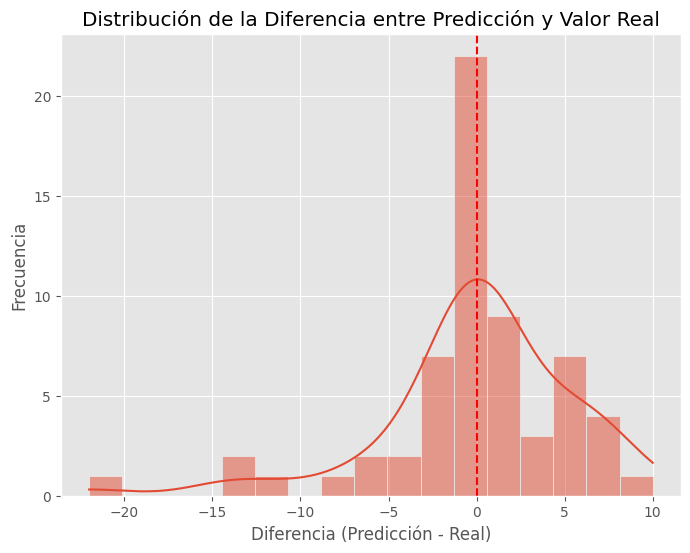

In [ ]:
differences = y_pred - y_test

# Graficar la distribución de las diferencias
plt.figure(figsize=(8, 6))
sns.histplot(differences, kde=True)
plt.axvline(0, color='red', linestyle='--')  # Línea en 0 para ver la tendencia
plt.xlabel('Diferencia (Predicción - Real)')
plt.ylabel('Frecuencia')
plt.title('Distribución de la Diferencia entre Predicción y Valor Real')
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE): {mae}')

Mean Absolute Error (MAE): 3.5161290322580645


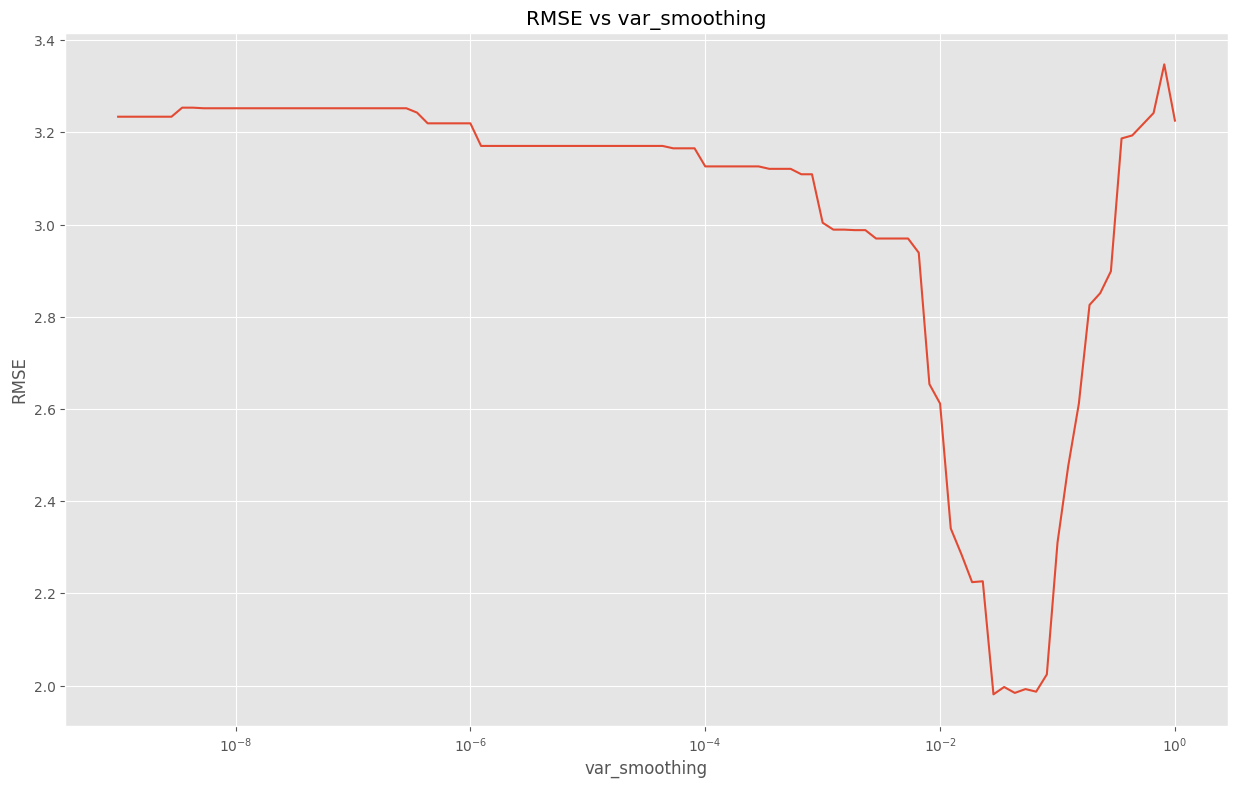

In [ ]:
results = pd.DataFrame(modelo.cv_results_)

# RMSE (convertir de negativo a positivo)
results["rmse"] = -results["mean_test_score"]

# Extraer var_smoothing
results["var_smoothing"] = results["param_regressor__var_smoothing"]

# Graficar
plt.plot(results["var_smoothing"], results["rmse"])
plt.xscale("log")
plt.xlabel("var_smoothing")
plt.ylabel("RMSE")
plt.title("RMSE vs var_smoothing")
plt.show()